In [19]:
import numpy as np
import torch as th
import matplotlib.pyplot as plt
from cnn_surgery.utils.load_dataset import load_dataset
from cnn_surgery.lenses.regressor_lens import get_regressor_lens

In [2]:
early = load_dataset('mnist', metrics_file='metrics_merged_mnist_early.csv', load_class_acc=True, stage='early')
middle = load_dataset('mnist', metrics_file='metrics_merged_mnist_middle.csv', load_class_acc=True, stage='middle')
final = load_dataset('mnist', metrics_file='metrics_merged.csv', load_class_acc=True, stage='final')

train_early, test_early, val_early = early
train_middle, test_middle, val_middle = middle
train_final, test_final, val_final = final

weights_train = np.concatenate([train_early[0], train_middle[0], train_final[0]])
weights_val = np.concatenate([val_early[0], val_middle[0], val_final[0]])

accuracies_train = np.concatenate([train_early[1][:, -10:], train_middle[1][:, -10:], train_final[1][:, -10:]])
accuracies_val = np.concatenate([val_early[1][:, -10:], val_middle[1][:, -10:], val_final[1][:, -10:]])

dirname:  /Users/ilic/Documents/CWI/Explainability and Interpretability/WeightSpaceClassifier/model_zoo/mnist


dirname:  /Users/ilic/Documents/CWI/Explainability and Interpretability/WeightSpaceClassifier/model_zoo/mnist


dirname:  /Users/ilic/Documents/CWI/Explainability and Interpretability/WeightSpaceClassifier/model_zoo/mnist


In [5]:
meta_network = get_regressor_lens(weights_train, accuracies_train, weights_val, accuracies_val, device='cpu')


Starting training of RegressorLens:
Epoch   1 ─ val loss 0.026767 | val MAE 0.097761 | duration 1.2s
Epoch   2 ─ val loss 0.023490 | val MAE 0.084322 | duration 0.8s
Epoch   3 ─ val loss 0.020960 | val MAE 0.079012 | duration 0.8s
Epoch   4 ─ val loss 0.019009 | val MAE 0.070916 | duration 0.9s
Epoch   5 ─ val loss 0.017108 | val MAE 0.066836 | duration 0.8s
Epoch   6 ─ val loss 0.017055 | val MAE 0.065562 | duration 0.8s
Epoch   7 ─ val loss 0.016529 | val MAE 0.064354 | duration 0.8s
Epoch   8 ─ val loss 0.015783 | val MAE 0.062592 | duration 0.8s
Epoch   9 ─ val loss 0.015376 | val MAE 0.061483 | duration 1.0s
Epoch  10 ─ val loss 0.016017 | val MAE 0.064040 | duration 1.1s
Epoch  11 ─ val loss 0.015103 | val MAE 0.060793 | duration 0.9s
Epoch  12 ─ val loss 0.015549 | val MAE 0.060329 | duration 1.6s
Epoch  13 ─ val loss 0.015144 | val MAE 0.060001 | duration 0.9s
Epoch  14 ─ val loss 0.015368 | val MAE 0.061479 | duration 0.8s
Epoch  15 ─ val loss 0.015278 | val MAE 0.060306 | du

In [604]:
# pick a random network to play around with
MODEL_IDX = -10
model_weights = weights_val[MODEL_IDX]
model_weights_tensor = th.tensor(model_weights, dtype=th.float32, requires_grad=True).unsqueeze(0)
model_weights_tensor.retain_grad()
model_accuracies = accuracies_val[MODEL_IDX]
pred = meta_network(model_weights_tensor).squeeze(0)

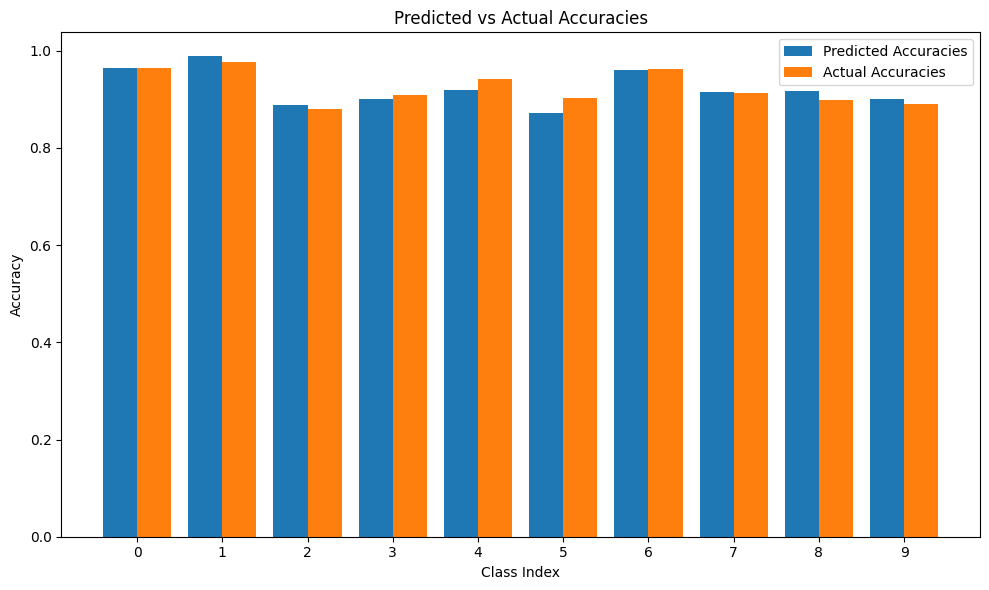

In [605]:
# plot
fig, ax = plt.subplots(figsize=(10, 6))

# Define the positions for the bars
indices = np.arange(len(pred))
width = 0.4  # Width of the bars

# Plot predicted accuracies
ax.bar(indices - width/2, pred.detach().numpy(), width, label='Predicted Accuracies')

# Plot actual accuracies
ax.bar(indices + width/2, model_accuracies, width, label='Actual Accuracies')

# Add labels, title, and legend
ax.set_title("Predicted vs Actual Accuracies")
ax.set_xlabel("Class Index")
ax.set_ylabel("Accuracy")
ax.set_xticks(indices)
ax.legend()

plt.tight_layout()
plt.show()

In [744]:
def simple_loss_fn(pred, target_class):
    """ A simple loss that encourages unlearning of a specific class."""
    return pred[target_class]

def boost_loss_fn(pred, target_class, beta=0.1):
    """ Encourages unlearning of a specific class, whilst boosting accuracy on other classes."""
    mask = -th.ones_like(pred) * beta
    mask[target_class] = 1
    return (mask * pred).mean()

def unlearning_and_faithfulness_loss(pred, true, target_class, alpha=1.0):
    """ Encourages unlearning of a specific class, whilst maintaining faithfulness to the true accuracies."""
    unlearning_loss = simple_loss_fn(pred, target_class)
    faithfulness_loss = ((true - pred)**2).mean()
    return unlearning_loss + alpha * faithfulness_loss

In [751]:
loss_fn = unlearning_and_faithfulness_loss
directions = []
true = model_accuracies[MODEL_IDX]
for target_class in range(10):
    model_weights_tensor.grad = None
    # zero grad
    pred = meta_network(model_weights_tensor).squeeze(0)
    loss = loss_fn(pred, true, target_class=target_class)
    loss.backward()
    directions.append(-model_weights_tensor.grad.squeeze(0).detach().numpy())
    meta_network.zero_grad()

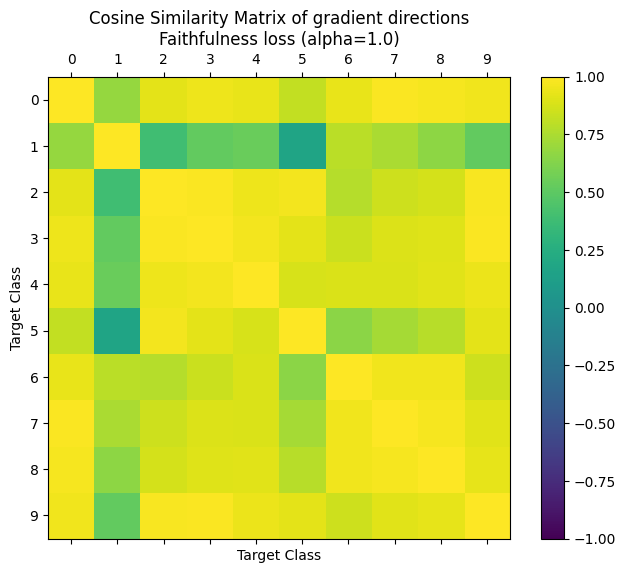

In [752]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute cosine similarity matrix
cos_sim_matrix = cosine_similarity(np.array(directions))

# Plot the cosine similarity matrix
fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.matshow(cos_sim_matrix, cmap='viridis', vmin=-1, vmax=1)

# Add colorbar
fig.colorbar(cax)

# Add labels and title
ax.set_title("Cosine Similarity Matrix of gradient directions\nFaithfulness loss (alpha=1.0)")
ax.set_xlabel("Target Class")
ax.set_ylabel("Target Class")
ax.set_xticks(range(len(directions)))
ax.set_yticks(range(len(directions)))

plt.show()